In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import pickle

with open(f"activations_save/activations_vit_cifar100_rank.pkl", "rb") as f:
    activations = pickle.load(f)

In [3]:
for key in activations.keys():
    print(key)

layer_0.input_layernorm
layer_0.self_attn_k_proj
layer_0.self_attn_v_proj
layer_0.self_attn_q_proj
layer_0.self_attn_o_proj
layer_0.post_attention_layernorm
layer_0.mlp_gate_proj
layer_0.mlp_up_proj
layer_0.mlp_down_proj
layer_1.input_layernorm
layer_1.self_attn_k_proj
layer_1.self_attn_v_proj
layer_1.self_attn_q_proj
layer_1.self_attn_o_proj
layer_1.post_attention_layernorm
layer_1.mlp_gate_proj
layer_1.mlp_up_proj
layer_1.mlp_down_proj
layer_2.input_layernorm
layer_2.self_attn_k_proj
layer_2.self_attn_v_proj
layer_2.self_attn_q_proj
layer_2.self_attn_o_proj
layer_2.post_attention_layernorm
layer_2.mlp_gate_proj
layer_2.mlp_up_proj
layer_2.mlp_down_proj
layer_3.input_layernorm
layer_3.self_attn_k_proj
layer_3.self_attn_v_proj
layer_3.self_attn_q_proj
layer_3.self_attn_o_proj
layer_3.post_attention_layernorm
layer_3.mlp_gate_proj
layer_3.mlp_up_proj
layer_3.mlp_down_proj
layer_4.input_layernorm
layer_4.self_attn_k_proj
layer_4.self_attn_v_proj
layer_4.self_attn_q_proj
layer_4.self_attn

In [20]:
activations['layer_0.mlp_up_proj']['input'][0].shape

torch.Size([16, 197, 3072])

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def channel_stats(x: torch.Tensor):
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    x = x.detach()
    
    C = x.shape[-1]
    X2d = x.reshape(-1, C).to(torch.float32)

    mean = X2d.mean(dim=0)
    std  = X2d.std(dim=0, unbiased=False)
    vmin = X2d.min(dim=0).values
    vmax = X2d.max(dim=0).values
    return X2d, mean, std, vmin, vmax


def plot_channel_means(mean: torch.Tensor, title="Channel mean"):
    mean_np = mean.cpu().numpy()
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(mean_np)), mean_np, linewidth=1)
    plt.xlabel("Channel index")
    plt.ylabel("Mean over (batch*seqlen)")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

原始逐通道均值

X2d: (3152, 768) C= 768
mean: min/max = -0.5742231607437134 0.4136021137237549
std : min/max = 0.1639106720685959 1.0001887083053589
val : min/max = -2.296875 3.46875


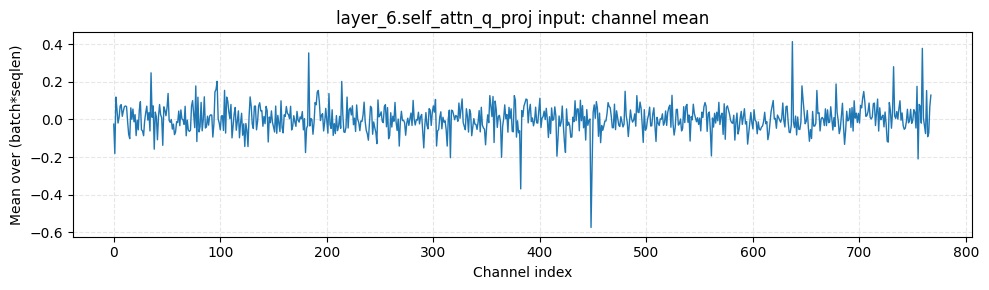

In [6]:
target_activation_name = 'layer_6.self_attn_q_proj'
x = activations[target_activation_name]["input"][0]  # shape: [B, ..., C]
x = x.reshape(-1, x.shape[-1])  # 转成 [N, C] 方便查看
X2d, mean, std, vmin, vmax = channel_stats(x)

print("X2d:", tuple(X2d.shape), "C=", X2d.shape[1])
print("mean: min/max =", mean.min().item(), mean.max().item())
print("std : min/max =", std.min().item(),  std.max().item())
print("val : min/max =", vmin.min().item(), vmax.max().item())

plot_channel_means(mean, title=f"{target_activation_name} input: channel mean")

减去低秩矩阵后的残差均值

compression ratio : 0.0625
R2d: (3152, 768) C= 768
mean: min/max = -0.009143523871898651 0.023110145702958107
std : min/max = 0.09922192245721817 0.24865561723709106
val : min/max = -1.4095853567123413 3.049842357635498


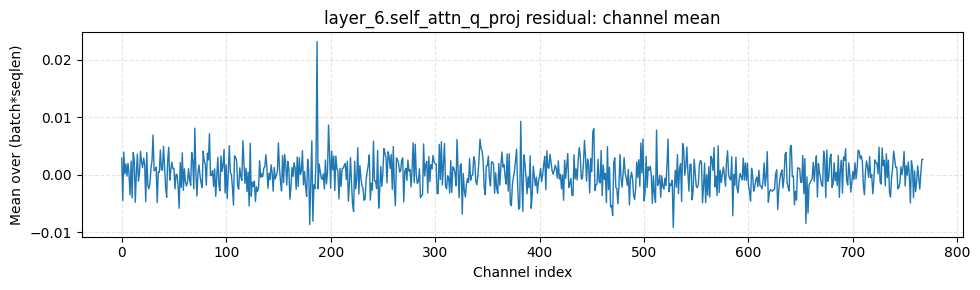

In [7]:
U, S, VT = torch.linalg.svd(x.to(torch.float32), full_matrices=False)
ratio = 1 / 16.0
print(f'compression ratio : {ratio}')
k = int(x.shape[-1] * ratio)
Q = U[:, :k]
B = torch.diag(S[:k]) @ VT[:k, :]
R = x - Q @ B
R2d, Rmean, Rstd, Rvmin, Rvmax = channel_stats(R)

print("R2d:", tuple(R2d.shape), "C=", R2d.shape[1])
print("mean: min/max =", Rmean.min().item(), Rmean.max().item())
print("std : min/max =", Rstd.min().item(),  Rstd.max().item())
print("val : min/max =", Rvmin.min().item(), Rvmax.max().item())

plot_channel_means(Rmean, title=f"{target_activation_name} residual: channel mean")

In [8]:
def stochastic_1bit_quantize(x: torch.Tensor):
    alpha = x.abs().mean().item()
    
    # x_clipped = torch.clamp(x, -alpha, alpha)
    # p = (x_clipped + alpha) / (2 * alpha)
    # rand_matrix = torch.rand_like(p)
    # binary_tensor = torch.where(rand_matrix < p, 1.0, -1.0)
    
    binary_tensor = torch.where(x > 0, 1.0, -1.0)
    
    bit_tensor = (binary_tensor > 0).to(torch.uint8)
    
    flat_bits = bit_tensor.flatten()
    original_numel = flat_bits.numel()
    
    pad_len = (8 - original_numel % 8) % 8
    if pad_len > 0:
        flat_bits = torch.nn.functional.pad(flat_bits, (0, pad_len), value=0)
    
    flat_bits = flat_bits.view(-1, 8)
    
    powers = torch.tensor([128, 64, 32, 16, 8, 4, 2, 1], dtype=torch.uint8, device=x.device)
    
    packed_tensor = (flat_bits * powers).sum(dim=1, dtype=torch.uint8)
    
    return packed_tensor, alpha, x.shape


def dequantize_1bit(packed_tensor: torch.Tensor, alpha: float, original_shape: torch.Size):
    powers = torch.tensor([128, 64, 32, 16, 8, 4, 2, 1], dtype=torch.uint8, device=packed_tensor.device)
    
    unpacked_bits = (packed_tensor.unsqueeze(1) & powers) > 0

    flat_bits = unpacked_bits.flatten()
    original_numel = original_shape[0] * original_shape[1]
    flat_bits = flat_bits[:original_numel]

    binary_tensor = torch.where(flat_bits, 1.0, -1.0)

    reconstructed_x = binary_tensor.view(original_shape) * alpha
    
    return reconstructed_x

In [9]:
import math
import torch
import torch.nn.functional as F

def stochastic_1bit_group_quantize(x: torch.Tensor, group_size: int = 1, eps: float = 1e-8):
    """
    按通道分组(最后一维C分组)的1-bit随机量化 + bit-pack
    返回:
      packed:  uint8 打包后的比特流 (一维)
      alpha_g: (G,) 每个通道组的缩放系数
      meta:    dict，包含反量化所需的形状/分组信息
    """
    assert x.is_floating_point(), "x 需要是浮点张量"
    assert group_size >= 1

    orig_shape = tuple(x.shape)
    C = x.shape[-1]
    X2d = x.reshape(-1, C)  # (N, C)
    N = X2d.shape[0]

    # 1) 按组对C做padding，保证能整除group_size
    G = math.ceil(C / group_size)
    Cp = G * group_size
    pad_c = Cp - C
    if pad_c > 0:
        X2d = F.pad(X2d, (0, pad_c), value=0.0)  # pad last dim: (left=0,right=pad_c)

    # 2) reshape成 (N, G, group_size)
    Xg = X2d.view(N, G, group_size)

    # 3) 每组一个alpha：在 (N, group_size) 上求 mean(|x|)
    alpha_g = Xg.abs().mean(dim=(0, 2))  # (G,)
    alpha_g = alpha_g.clamp_min(eps)     # 防止除0

    # # 4) clamp + 概率p + 随机二值化（按组广播alpha）
    # a = alpha_g.view(1, G, 1)  # broadcast到(N,G,group)
    # Xc = torch.clamp(Xg, -a, a)
    # p = (Xc + a) / (2 * a)     # in [0,1]
    # binary = torch.where(torch.rand_like(p) < p, 1.0, -1.0)
    
    binary = torch.where(Xg > 0, 1.0, -1.0)

    # 5) bit-pack：{-1,+1}->{0,1} 然后按8个bit打包到uint8
    bits = (binary > 0).to(torch.uint8).reshape(-1)  # 展平

    pad_bits = (8 - (bits.numel() % 8)) % 8
    if pad_bits > 0:
        bits = F.pad(bits, (0, pad_bits), value=0)

    bits8 = bits.view(-1, 8)
    powers = torch.tensor([128, 64, 32, 16, 8, 4, 2, 1], dtype=torch.uint8, device=x.device)
    packed = (bits8 * powers).sum(dim=1, dtype=torch.uint8)

    meta = {
        "orig_shape": orig_shape,
        "C": C,
        "group_size": group_size,
        "Cp": Cp,
        "pad_bits": pad_bits,
    }
    return packed, alpha_g, meta


def dequantize_1bit_group(packed: torch.Tensor, alpha_g: torch.Tensor, meta: dict):
    """
    对 stochastic_1bit_group_quantize 的反量化
    """
    orig_shape = meta["orig_shape"]
    C = meta["C"]
    group_size = meta["group_size"]
    Cp = meta["Cp"]

    # 1) unpack bits
    powers = torch.tensor([128, 64, 32, 16, 8, 4, 2, 1], dtype=torch.uint8, device=packed.device)
    unpacked = ((packed.unsqueeze(1) & powers) > 0).reshape(-1)  # bool

    # 2) 截断到需要的元素数：N*Cp
    N = int(torch.tensor(orig_shape[:-1]).prod().item()) if len(orig_shape) > 1 else 1
    need = N * Cp
    unpacked = unpacked[:need]

    # 3) {0,1}->{-1,+1}
    binary = torch.where(unpacked, 1.0, -1.0).view(N, Cp)

    # 4) 组alpha展开到每个通道列
    # alpha_g: (G,) -> (Cp,)
    alpha_cols = alpha_g.repeat_interleave(group_size)[:Cp].to(dtype=binary.dtype, device=binary.device)
    Xrec = binary * alpha_cols.view(1, Cp)

    # 5) 去掉C方向padding，并reshape回原形状
    Xrec = Xrec[:, :C].view(*orig_shape)
    return Xrec

In [10]:
import math
import torch
import torch.nn.functional as F

def _next_pow2(n: int) -> int:
    return 1 if n <= 1 else 1 << (n - 1).bit_length()

def fwht_lastdim(x: torch.Tensor, normalize: bool = True) -> torch.Tensor:
    """
    Fast Walsh–Hadamard Transform along last dim.
    要求 last dim = power of 2
    """
    n = x.shape[-1]
    assert (n & (n - 1) == 0), f"FWHT需要长度为2的幂，当前 n={n}"
    y = x
    h = 1
    while h < n:
        y = y.view(*y.shape[:-1], -1, 2 * h)
        a = y[..., :h]
        b = y[..., h:2*h]
        y = torch.cat([a + b, a - b], dim=-1)
        y = y.view(*x.shape[:-1], n)
        h *= 2
    if normalize:
        y = y / math.sqrt(n)
    return y

def srht_rotate_channels(x: torch.Tensor, generator: torch.Generator | None = None):
    """
    SRHT: x -> (x * d) @ H  (沿最后一维做Hadamard)
    返回: x_rot, meta(包含d与padding信息)
    """
    assert x.is_floating_point()
    orig_shape = tuple(x.shape)
    C = x.shape[-1]
    Cp2 = _next_pow2(C)

    x2d = x.reshape(-1, C)  # (N, C)
    if Cp2 != C:
        x2d = F.pad(x2d, (0, Cp2 - C), value=0.0)  # pad channels

    # random Rademacher signs d in {+1,-1}
    # 用int8生成再转float，减少随机开销
    if generator is None:
        d = torch.empty((Cp2,), device=x.device).bernoulli_(0.5).mul_(2).sub_(1)
    else:
        d = torch.empty((Cp2,), device=x.device).bernoulli_(0.5, generator=generator).mul_(2).sub_(1)

    x_signed = x2d * d.view(1, Cp2)
    x_rot = fwht_lastdim(x_signed, normalize=True)  # (N, Cp2)

    meta = {"orig_shape": orig_shape, "C": C, "Cp2": Cp2, "d": d}
    return x_rot.view(*orig_shape[:-1], Cp2), meta

def srht_unrotate_channels(x_rot: torch.Tensor, meta: dict):
    """
    inverse SRHT: x_rot -> H @ x_rot -> * d
    注意：fwht在normalize=True时自逆（同一个fwht调用两次就是逆）
    """
    C = meta["C"]
    Cp2 = meta["Cp2"]
    d = meta["d"]

    y2d = x_rot.reshape(-1, Cp2)
    y = fwht_lastdim(y2d, normalize=True)
    y = y * d.view(1, Cp2)
    y = y[:, :C]  # unpad channels
    return y.view(*meta["orig_shape"])

def quantize_R_with_srht(R: torch.Tensor, group_size: int = 32, eps: float = 1e-8, generator: torch.Generator | None = None):
    """
    R --SRHT--> R_rot --1bit group quant--> packed, alpha_g, meta_all
    """
    R_rot, meta_h = srht_rotate_channels(R.to(torch.float32), generator=generator)
    packed, alpha_g, meta_q = stochastic_1bit_group_quantize(R_rot, group_size=group_size, eps=eps)
    meta_all = {"hadamard": meta_h, "quant": meta_q}
    return packed, alpha_g, meta_all

def dequantize_R_with_srht(packed: torch.Tensor, alpha_g: torch.Tensor, meta_all: dict):
    """
    packed --dequant--> R_rot_hat --invSRHT--> R_hat
    """
    R_rot_hat = dequantize_1bit_group(packed, alpha_g, meta_all["quant"])
    R_hat = srht_unrotate_channels(R_rot_hat, meta_all["hadamard"])
    return R_hat

In [13]:
attn_target_activation_names = [f'layer_{x}.self_attn_q_proj' for x in range(12)]
mlp_target_activation_names = [f'layer_{x}.mlp_up_proj' for x in range(12)]
compression_ratios = [1/8.0, 1/16.0, 1/32.0]

# attn
for target_activation_name in attn_target_activation_names:
    print(f'activation name : {target_activation_name}')
    x = activations[target_activation_name]["input"][0]  # shape: [B, ..., C]
    x = x.reshape(-1, x.shape[-1])  # 转成 [N, C] 方便查看
    U, S, VT = torch.linalg.svd(x.to(torch.float32), full_matrices=False)
    for ratio in compression_ratios:
        print(f'compression ratio : {ratio}')
        k = int(x.shape[-1] * ratio)
        Q = U[:, :k]
        B = torch.diag(S[:k]) @ VT[:k, :]
        R = x - Q @ B
        mem_original = R.element_size() * R.numel() / 1024  # KB
        
        print(f'---method 1: 统一缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_quantize(R)
        reconstructed_R = dequantize_1bit(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 2: 分组缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_group_quantize(R)
        reconstructed_R = dequantize_1bit_group(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 3: 哈达玛+分组缩放系数---')
        packed_R, alpha, shape = quantize_R_with_srht(R)
        reconstructed_R = dequantize_R_with_srht(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        

activation name : layer_0.self_attn_q_proj
compression ratio : 0.125
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.000048
low rank + 1-bit MSE: 0.000020
low rank MSE after linear layer: 0.036365
low rank + 1-bit MSE after linear layer: 0.015592

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.000048
low rank + 1-bit MSE: 0.000018
low rank MSE after linear layer: 0.036852
low rank + 1-bit MSE after linear layer: 0.014238

---method 3: 哈达玛+分组缩放系数---
压缩率: 24.0x
low rank MSE: 0.000048
low rank + 1-bit MSE: 0.000016
low rank MSE after linear layer: 0.036717
low rank + 1-bit MSE after linear layer: 0.012271

compression ratio : 0.0625
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.000151
low rank + 1-bit MSE: 0.000076
low rank MSE after linear layer: 0.116980
low rank + 1-bit MSE after linear layer: 0.058478

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.000151
low rank + 1-bit MSE: 0.000062
low rank MSE after linear layer: 0.116665
low rank + 1-bit MSE after linear layer: 0.047

In [24]:
attn_target_activation_names = [f'layer_{x}.self_attn_q_proj' for x in range(12)]
# mlp_target_activation_names = [f'layer_{x}.mlp_up_proj' for x in range(12)]
mlp_target_activation_names = [f'layer_{x}.mlp_gate_proj' for x in range(8,9)]
compression_ratios = [1/8.0, 1/16.0, 1/32.0]

# attn
for target_activation_name in mlp_target_activation_names:
    print(f'activation name : {target_activation_name}')
    x = activations[target_activation_name]["input"][0]  # shape: [B, ..., C]
    x = x.reshape(-1, x.shape[-1])  # 转成 [N, C] 方便查看
    U, S, VT = torch.linalg.svd(x.to(torch.float32), full_matrices=False)
    for ratio in compression_ratios:
        print(f'compression ratio : {ratio}')
        k = int(x.shape[-1] * ratio)
        Q = U[:, :k]
        B = torch.diag(S[:k]) @ VT[:k, :]
        R = x - Q @ B
        mem_original = R.element_size() * R.numel() / 1024  # KB
        
        print(f'---method 1: 统一缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_quantize(R)
        reconstructed_R = dequantize_1bit(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 2: 分组缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_group_quantize(R)
        reconstructed_R = dequantize_1bit_group(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 3: 哈达玛+分组缩放系数---')
        packed_R, alpha, shape = quantize_R_with_srht(R)
        reconstructed_R = dequantize_R_with_srht(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        

activation name : layer_8.mlp_gate_proj
compression ratio : 0.125
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.074359
low rank + 1-bit MSE: 0.030051
low rank MSE after linear layer: 57.025070
low rank + 1-bit MSE after linear layer: 22.989269

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.074359
low rank + 1-bit MSE: 0.029744
low rank MSE after linear layer: 56.994850
low rank + 1-bit MSE after linear layer: 22.802036

---method 3: 哈达玛+分组缩放系数---
压缩率: 24.0x
low rank MSE: 0.074359
low rank + 1-bit MSE: 0.025856
low rank MSE after linear layer: 57.293320
low rank + 1-bit MSE after linear layer: 19.898993

compression ratio : 0.0625
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.114480
low rank + 1-bit MSE: 0.045817
low rank MSE after linear layer: 88.301445
low rank + 1-bit MSE after linear layer: 35.243061

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.114480
low rank + 1-bit MSE: 0.045346
low rank MSE after linear layer: 87.905716
low rank + 1-bit MSE after linear layer:

In [23]:
from meft.linalg.qb import randomized_qb

attn_target_activation_names = [f'layer_{x}.self_attn_q_proj' for x in range(12)]
# mlp_target_activation_names = [f'layer_{x}.mlp_up_proj' for x in range(12)]
mlp_target_activation_names = [f'layer_{x}.mlp_gate_proj' for x in range(8,9)]
compression_ratios = [1/8.0, 1/16.0, 1/32.0]

# attn
for target_activation_name in mlp_target_activation_names:
    print(f'activation name : {target_activation_name}')
    x = activations[target_activation_name]["input"][0]  # shape: [B, ..., C]
    x = x.reshape(-1, x.shape[-1])  # 转成 [N, C] 方便查看
    print(x.shape)
    # U, S, VT = torch.linalg.svd(x.to(torch.float32), full_matrices=False)
    for ratio in compression_ratios:
        print(f'compression ratio : {ratio}')
        k = int(x.shape[-1] * ratio)
        # Q = U[:, :k]
        # B = torch.diag(S[:k]) @ VT[:k, :]
        Q, B = randomized_qb(x.to(torch.float32), k)
        R = x - Q @ B
        mem_original = R.element_size() * R.numel() / 1024  # KB
        
        print(f'---method 1: 统一缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_quantize(R)
        reconstructed_R = dequantize_1bit(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 2: 分组缩放系数---')
        packed_R, alpha, shape = stochastic_1bit_group_quantize(R)
        reconstructed_R = dequantize_1bit_group(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        
        
        print(f'---method 3: 哈达玛+分组缩放系数---')
        packed_R, alpha, shape = quantize_R_with_srht(R)
        reconstructed_R = dequantize_R_with_srht(packed_R, alpha, shape)
        mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB
        print(f"压缩率: {mem_original/mem_quantized:.1f}x")
        lowrank_mse = torch.mean((x - Q @ B)**2)
        lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)
        print(f'low rank MSE: {lowrank_mse.item():.6f}')
        print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')
        W = torch.randn(x.shape[-1], x.shape[-1])
        A = x.to(torch.float32) @ W
        A1 = Q @ B @ W
        A2 = (Q @ B + reconstructed_R) @ W
        A1_mse = torch.mean((A - A1)**2)
        A2_mse = torch.mean((A - A2)**2)
        print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
        print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')
        print()
        

activation name : layer_8.mlp_gate_proj
torch.Size([3152, 768])
compression ratio : 0.125
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.092785
low rank + 1-bit MSE: 0.036543
low rank MSE after linear layer: 71.347443
low rank + 1-bit MSE after linear layer: 28.086023

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.092785
low rank + 1-bit MSE: 0.036062
low rank MSE after linear layer: 71.406395
low rank + 1-bit MSE after linear layer: 27.721453

---method 3: 哈达玛+分组缩放系数---
压缩率: 24.0x
low rank MSE: 0.092785
low rank + 1-bit MSE: 0.030827
low rank MSE after linear layer: 71.432396
low rank + 1-bit MSE after linear layer: 23.665220

compression ratio : 0.0625
---method 1: 统一缩放系数---
压缩率: 32.0x
low rank MSE: 0.138533
low rank + 1-bit MSE: 0.054779
low rank MSE after linear layer: 107.462547
low rank + 1-bit MSE after linear layer: 42.344761

---method 2: 分组缩放系数---
压缩率: 32.0x
low rank MSE: 0.138533
low rank + 1-bit MSE: 0.054075
low rank MSE after linear layer: 106.565933
low rank + 1-b

In [302]:
W1 = torch.randn(x.shape[-1], x.shape[-1])
W2 = torch.randn(x.shape[-1], x.shape[-1])
A = x.to(torch.float32) @ W1 @ W2
A1 = Q @ B @ W1 @ W2
A2 = (Q @ B + reconstructed_R) @ W1 @ W2

A1_mse = torch.mean((A - A1)**2)
A2_mse = torch.mean((A - A2)**2)
print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')

low rank MSE after linear layer: 22800.183594
low rank + 1-bit MSE after linear layer: 9095.703125


In [304]:
print(R.dtype)
packed_R, alpha, shape = stochastic_1bit_group_quantize(R)

reconstructed_R = dequantize_1bit_group(packed_R, alpha, shape)

mem_original = R.element_size() * R.numel() / 1024  # KB
mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB

print(f"=== 显存压缩测试 ===")
print(f"原始张量 (FP16) 显存占用: {mem_original:.2f} KB")
print(f"量化张量 (1-bit) 显存占用: {mem_quantized:.2f} KB (压缩率: {mem_original/mem_quantized:.1f}x)")

print(f"\n=== 数值无偏性测试 ===")
print(f"原始矩阵均值: {R.mean().item():.6f}")
print(f"重构矩阵均值: {reconstructed_R.mean().item():.6f} (极为接近 0)")

print(f"\n原始矩阵前5个值: \n{R[0, :5].numpy()}")
print(f"重构矩阵前5个值 (+/- alpha_g[0]={alpha[0]:.4f}): \n{reconstructed_R[0, :5].numpy()}")

torch.float32
=== 显存压缩测试 ===
原始张量 (FP16) 显存占用: 9456.00 KB
量化张量 (1-bit) 显存占用: 295.50 KB (压缩率: 32.0x)

=== 数值无偏性测试 ===
原始矩阵均值: 0.000075
重构矩阵均值: 0.000036 (极为接近 0)

原始矩阵前5个值: 
[-0.32782727  0.04399629 -0.11060614 -0.02655696  0.09933537]
重构矩阵前5个值 (+/- alpha_g[0]=0.1282): 
[-0.1282361   0.10713354 -0.155944   -0.15376805  0.1706206 ]


In [305]:
lowrank_mse = torch.mean((x - Q @ B)**2)
lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)

print(f'low rank MSE: {lowrank_mse.item():.6f}')
print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')

low rank MSE: 0.038813
low rank + 1-bit MSE: 0.015154


In [306]:
A = x.to(torch.float32) @ W
A1 = Q @ B @ W
A2 = (Q @ B + reconstructed_R) @ W

A1_mse = torch.mean((A - A1)**2)
A2_mse = torch.mean((A - A2)**2)
print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')

low rank MSE after linear layer: 29.738930
low rank + 1-bit MSE after linear layer: 11.636232


In [307]:
A = x.to(torch.float32) @ W1 @ W2
A1 = Q @ B @ W1 @ W2
A2 = (Q @ B + reconstructed_R) @ W1 @ W2

A1_mse = torch.mean((A - A1)**2)
A2_mse = torch.mean((A - A2)**2)
print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')

low rank MSE after linear layer: 22800.183594
low rank + 1-bit MSE after linear layer: 8895.030273


使用哈达玛

In [308]:
import math
import torch
import torch.nn.functional as F

def _next_pow2(n: int) -> int:
    return 1 if n <= 1 else 1 << (n - 1).bit_length()

def fwht_lastdim(x: torch.Tensor, normalize: bool = True) -> torch.Tensor:
    """
    Fast Walsh–Hadamard Transform along last dim.
    要求 last dim = power of 2
    """
    n = x.shape[-1]
    assert (n & (n - 1) == 0), f"FWHT需要长度为2的幂，当前 n={n}"
    y = x
    h = 1
    while h < n:
        y = y.view(*y.shape[:-1], -1, 2 * h)
        a = y[..., :h]
        b = y[..., h:2*h]
        y = torch.cat([a + b, a - b], dim=-1)
        y = y.view(*x.shape[:-1], n)
        h *= 2
    if normalize:
        y = y / math.sqrt(n)
    return y

def srht_rotate_channels(x: torch.Tensor, generator: torch.Generator | None = None):
    """
    SRHT: x -> (x * d) @ H  (沿最后一维做Hadamard)
    返回: x_rot, meta(包含d与padding信息)
    """
    assert x.is_floating_point()
    orig_shape = tuple(x.shape)
    C = x.shape[-1]
    Cp2 = _next_pow2(C)

    x2d = x.reshape(-1, C)  # (N, C)
    if Cp2 != C:
        x2d = F.pad(x2d, (0, Cp2 - C), value=0.0)  # pad channels

    # random Rademacher signs d in {+1,-1}
    # 用int8生成再转float，减少随机开销
    if generator is None:
        d = torch.empty((Cp2,), device=x.device).bernoulli_(0.5).mul_(2).sub_(1)
    else:
        d = torch.empty((Cp2,), device=x.device).bernoulli_(0.5, generator=generator).mul_(2).sub_(1)

    x_signed = x2d * d.view(1, Cp2)
    x_rot = fwht_lastdim(x_signed, normalize=True)  # (N, Cp2)

    meta = {"orig_shape": orig_shape, "C": C, "Cp2": Cp2, "d": d}
    return x_rot.view(*orig_shape[:-1], Cp2), meta

def srht_unrotate_channels(x_rot: torch.Tensor, meta: dict):
    """
    inverse SRHT: x_rot -> H @ x_rot -> * d
    注意：fwht在normalize=True时自逆（同一个fwht调用两次就是逆）
    """
    C = meta["C"]
    Cp2 = meta["Cp2"]
    d = meta["d"]

    y2d = x_rot.reshape(-1, Cp2)
    y = fwht_lastdim(y2d, normalize=True)
    y = y * d.view(1, Cp2)
    y = y[:, :C]  # unpad channels
    return y.view(*meta["orig_shape"])

def quantize_R_with_srht(R: torch.Tensor, group_size: int = 32, eps: float = 1e-8, generator: torch.Generator | None = None):
    """
    R --SRHT--> R_rot --1bit group quant--> packed, alpha_g, meta_all
    """
    R_rot, meta_h = srht_rotate_channels(R.to(torch.float32), generator=generator)
    packed, alpha_g, meta_q = stochastic_1bit_group_quantize(R_rot, group_size=group_size, eps=eps)
    meta_all = {"hadamard": meta_h, "quant": meta_q}
    return packed, alpha_g, meta_all

def dequantize_R_with_srht(packed: torch.Tensor, alpha_g: torch.Tensor, meta_all: dict):
    """
    packed --dequant--> R_rot_hat --invSRHT--> R_hat
    """
    R_rot_hat = dequantize_1bit_group(packed, alpha_g, meta_all["quant"])
    R_hat = srht_unrotate_channels(R_rot_hat, meta_all["hadamard"])
    return R_hat

In [309]:
group_size = 1

packed_R, alpha_g, meta_all = quantize_R_with_srht(R, group_size=group_size)
reconstructed_R = dequantize_R_with_srht(packed_R, alpha_g, meta_all)

mem_original = R.element_size() * R.numel() / 1024  # KB
mem_quantized = packed_R.element_size() * packed_R.numel() / 1024 # KB

print(f"=== 显存压缩测试 ===")
print(f"原始张量 (FP16) 显存占用: {mem_original:.2f} KB")
print(f"量化张量 (1-bit) 显存占用: {mem_quantized:.2f} KB (压缩率: {mem_original/mem_quantized:.1f}x)")

print(f"\n=== 数值无偏性测试 ===")
print(f"原始矩阵均值: {R.mean().item():.6f}")
print(f"重构矩阵均值: {reconstructed_R.mean().item():.6f} (极为接近 0)")

print(f"\n原始矩阵前5个值: \n{R[0, :5].numpy()}")
print(f"重构矩阵前5个值 (+/- alpha_g[0]={alpha[0]:.4f}): \n{reconstructed_R[0, :5].numpy()}")

=== 显存压缩测试 ===
原始张量 (FP16) 显存占用: 9456.00 KB
量化张量 (1-bit) 显存占用: 394.00 KB (压缩率: 24.0x)

=== 数值无偏性测试 ===
原始矩阵均值: 0.000075
重构矩阵均值: 0.000224 (极为接近 0)

原始矩阵前5个值: 
[-0.32782727  0.04399629 -0.11060614 -0.02655696  0.09933537]
重构矩阵前5个值 (+/- alpha_g[0]=0.1282): 
[-0.20909894  0.01764099 -0.02960638 -0.05313276  0.13833073]


In [310]:
lowrank_mse = torch.mean((x - Q @ B)**2)
lq_mse = torch.mean((x - (Q @ B + reconstructed_R))**2)

print(f'low rank MSE: {lowrank_mse.item():.6f}')
print(f'low rank + 1-bit MSE: {lq_mse.item():.6f}')

low rank MSE: 0.038813
low rank + 1-bit MSE: 0.013027


In [311]:
A = x.to(torch.float32) @ W
A1 = Q @ B @ W
A2 = (Q @ B + reconstructed_R) @ W

A1_mse = torch.mean((A - A1)**2)
A2_mse = torch.mean((A - A2)**2)
print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')

low rank MSE after linear layer: 29.738930
low rank + 1-bit MSE after linear layer: 9.960093


In [312]:
A = x.to(torch.float32) @ W1 @ W2
A1 = Q @ B @ W1 @ W2
A2 = (Q @ B + reconstructed_R) @ W1 @ W2

A1_mse = torch.mean((A - A1)**2)
A2_mse = torch.mean((A - A2)**2)
print(f'low rank MSE after linear layer: {A1_mse.item():.6f}')
print(f'low rank + 1-bit MSE after linear layer: {A2_mse.item():.6f}')

low rank MSE after linear layer: 22800.183594
low rank + 1-bit MSE after linear layer: 7625.927246
